# Phase 9: 전체 모델 비교 — 두 그룹

평가관 피드백 반영: 5개 모델을 10-class와 4-class 두 그룹으로 비교.

**Group 1 (Architecture 효과)**: LR → LightGBM → MLP → RNN → Transformer (10-class)

**Group 2 (MDP/DQN 호환)**: LR → LightGBM → MLP (4-class)

작성일: 2026-05-23

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

OUTPUT_DIR = Path('../outputs')

with open(OUTPUT_DIR / 'all_models_comparison_10cls.json', encoding='utf-8') as f:
    comp10 = json.load(f)
with open(OUTPUT_DIR / 'all_models_comparison_4cls.json', encoding='utf-8') as f:
    comp4 = json.load(f)

print('=== 10-class Group ===')
for name, r in comp10.items():
    print(f'  {name:<25} Top-1={r["top1"]*100:.1f}%  Top-3={r["top3"]*100:.1f}%  CE={r["ce"]:.4f}')

print('\n=== 4-class Group ===')
for name, r in comp4.items():
    print(f'  {name:<22} Top-1={r["top1"]*100:.1f}%  Top-3={r["top3"]*100:.1f}%  CE={r["ce"]:.4f}')

=== 10-class Group ===
  Logistic Regression       Top-1=41.1%  Top-3=86.2%  CE=1.6142
  LightGBM                  Top-1=13.0%  Top-3=48.1%  CE=2.0872
  MLP (10-class)            Top-1=41.1%  Top-3=86.2%  CE=1.4697
  RNN (LSTM)                Top-1=66.9%  Top-3=94.8%  CE=0.8728
  Transformer (Model C)     Top-1=67.2%  Top-3=94.7%  CE=0.8682

=== 4-class Group ===
  Logistic Regression    Top-1=56.3%  Top-3=94.5%  CE=1.0516
  LightGBM               Top-1=60.8%  Top-3=96.6%  CE=0.8719
  MLP (Model B)          Top-1=60.9%  Top-3=96.6%  CE=0.8723


## Table 1: 10-class 비교 (Architecture 효과)

| 모델 | Architecture | Input | Top-1 | Macro-F1 | CE | MDP |
|------|-------------|-------|-------|----------|----|-----|
| Logistic Regression | Linear | 77d | 41.1%† | **5.9%** | 1.614 | ✅ |
| LightGBM | Tree (boosting) | 77d | 13.0%‡ | **7.2%** | 2.087 | ✅ |
| MLP | NN [128,128] | 77d | 41.1%† | **5.8%** | 1.470 | ✅ |
| **RNN (LSTM)** | LSTM 2-layer | 400×87 | **66.9%** | **28.8%** | 0.873 | ❌ |
| **Transformer** | 12-layer Enc. | 400×87 | **67.2%** | **30.1%** | 0.868 | ❌ |

† Strike만 예측 (majority collapse) → Macro-F1 ≈ 6% (random 수준)  
‡ 전 클래스 균등 예측 (inverse-freq 과보정) → Macro-F1 ≈ 7%

## Table 2: 4-class 비교 (MDP/DQN 호환)

| 모델 | Architecture | Top-1 | Macro-F1 | CE |
|------|-------------|-------|----------|----|
| Logistic Regression | Linear | 56.3% | 48.4% | 1.052 |
| LightGBM | Tree (boosting) | 60.8% | 53.3% | 0.872 |
| **MLP (Model B)** | NN [128,128] | **60.9%** | **53.8%** | 0.872 |

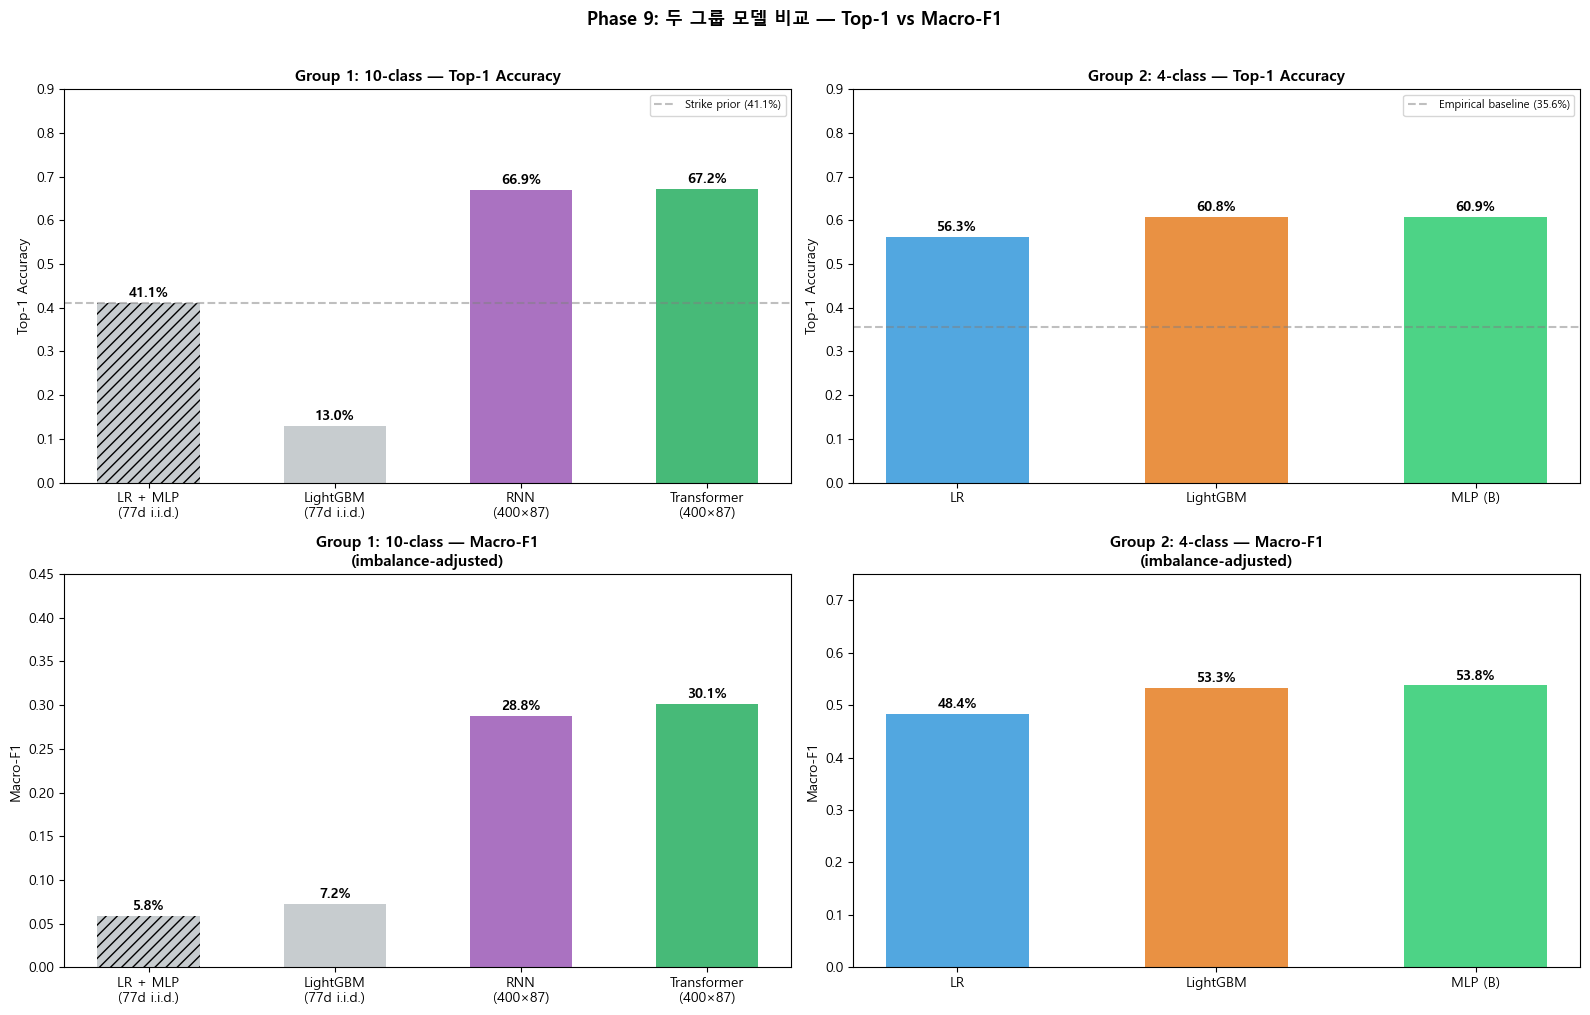

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── 공통 데이터 ───────────────────────────────────────────────────────────────
iid_top1  = (comp10['Logistic Regression']['top1'] + comp10['MLP (10-class)']['top1']) / 2
iid_mf1   = (comp10['Logistic Regression']['macro_f1'] + comp10['MLP (10-class)']['macro_f1']) / 2

bar_names10 = ['LR + MLP\n(77d i.i.d.)', 'LightGBM\n(77d i.i.d.)', 'RNN\n(400×87)', 'Transformer\n(400×87)']
top1_10     = [iid_top1, comp10['LightGBM']['top1'],
               comp10['RNN (LSTM)']['top1'], comp10['Transformer (Model C)']['top1']]
mf1_10      = [iid_mf1, comp10['LightGBM']['macro_f1'],
               comp10['RNN (LSTM)']['macro_f1'], comp10['Transformer (Model C)']['macro_f1']]
colors10    = ['#bdc3c7', '#bdc3c7', '#9b59b6', '#27ae60']
hatches10   = ['///', '', '', '']

names4  = list(comp4.keys())
top1_4  = [comp4[n]['top1'] for n in names4]
mf1_4   = [comp4[n]['macro_f1'] for n in names4]
colors4 = ['#3498db', '#e67e22', '#2ecc71']
short4  = ['LR', 'LightGBM', 'MLP (B)']


def draw_bar(ax, names, values, colors, hatches, title, ylabel, ylim, hline, hline_label, fmt='.1%'):
    bars = ax.bar(names, values, color=colors, alpha=0.85, width=0.55)
    for bar, hatch in zip(bars, hatches):
        bar.set_hatch(hatch)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, ylim)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, v + ylim * 0.015,
                format(v, fmt), ha='center', fontsize=10, fontweight='bold')
    if hline is not None:
        ax.axhline(hline, color='gray', linestyle='--', alpha=0.5, label=hline_label)
        ax.legend(fontsize=8)


# Row 0: Top-1 Accuracy
draw_bar(axes[0, 0], bar_names10, top1_10, colors10, hatches10,
         'Group 1: 10-class — Top-1 Accuracy', 'Top-1 Accuracy', 0.9,
         0.411, 'Strike prior (41.1%)')
draw_bar(axes[0, 1], short4, top1_4, colors4, ['']*3,
         'Group 2: 4-class — Top-1 Accuracy', 'Top-1 Accuracy', 0.9,
         0.356, 'Empirical baseline (35.6%)')

# Row 1: Macro-F1
draw_bar(axes[1, 0], bar_names10, mf1_10, colors10, hatches10,
         'Group 1: 10-class — Macro-F1\n(imbalance-adjusted)', 'Macro-F1', 0.45,
         None, None)
draw_bar(axes[1, 1], short4, mf1_4, colors4, ['']*3,
         'Group 2: 4-class — Macro-F1\n(imbalance-adjusted)', 'Macro-F1', 0.75,
         None, None)

plt.suptitle('Phase 9: 두 그룹 모델 비교 — Top-1 vs Macro-F1', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

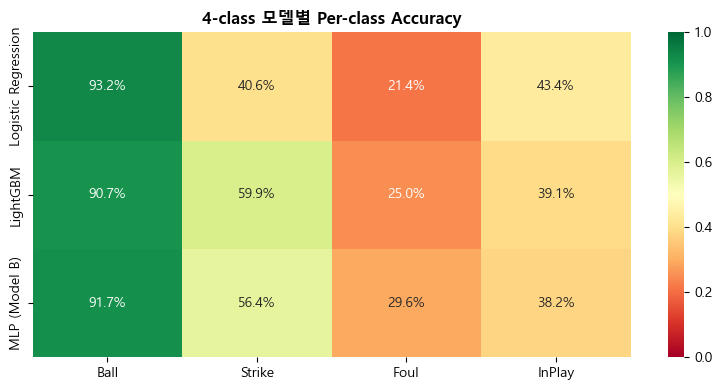

In [3]:
# 4-class: Per-class accuracy heatmap
cls4 = ['Ball','Strike','Foul','InPlay']
model_names = list(comp4.keys())
pca_matrix = []
for name in model_names:
    pca = comp4[name].get('per_class_accuracy', {})
    pca_matrix.append([pca.get(c, 0) for c in cls4])

pca_arr = np.array(pca_matrix)
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pca_arr, annot=True, fmt='.1%', cmap='RdYlGn',
            xticklabels=cls4, yticklabels=model_names, ax=ax,
            vmin=0, vmax=1)
ax.set_title('4-class 모델별 Per-class Accuracy', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


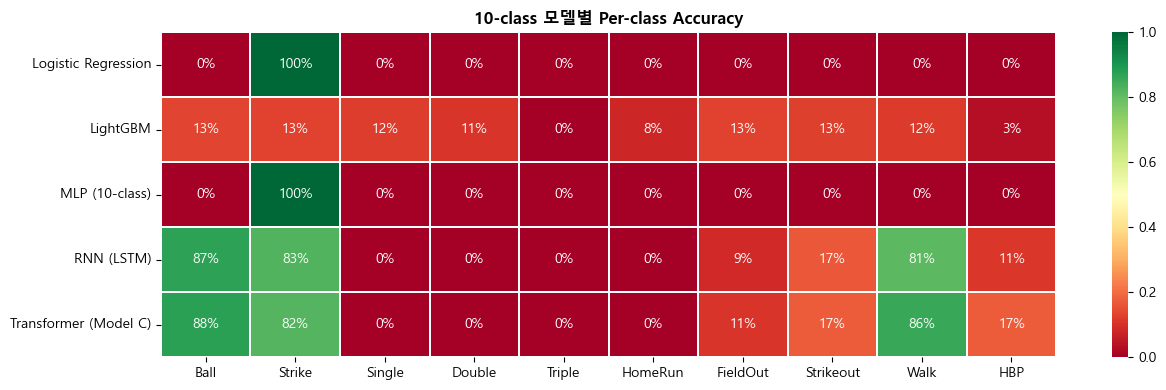

In [4]:
# 10-class: Per-class accuracy heatmap (5 models × 10 classes)
cls10 = ['Ball','Strike','Single','Double','Triple','HomeRun','FieldOut','Strikeout','Walk','HBP']
model_names10 = list(comp10.keys())
pca10_matrix = []
for name in model_names10:
    pca = comp10[name].get('per_class_accuracy', {})
    row = [pca.get(c, pca.get('HitByPitch', 0) if c == 'HBP' else 0) for c in
           ['Ball','Strike','Single','Double','Triple','HomeRun','FieldOut','Strikeout','Walk','HitByPitch']]
    pca10_matrix.append(row)

pca10_arr = np.array(pca10_matrix)
fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pca10_arr, annot=True, fmt='.0%', cmap='RdYlGn',
            xticklabels=cls10, yticklabels=model_names10, ax=ax,
            vmin=0, vmax=1, linewidths=0.3)
ax.set_title('10-class 모델별 Per-class Accuracy', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 핵심 발견

### 1. Macro-F1이 collapse를 정확히 드러냄 (10-class)
- Top-1만 보면 LR/MLP가 41.1%로 "나름 성능 있어 보임"
- Macro-F1 적용 시 LR **5.9%**, MLP **5.8%** → random classifier(10%) 이하
- "항상 Strike" 전략은 Strike F1≈0.58, 나머지 9개 F1=0 → 평균 5.8%
- Macro-F1은 다수 클래스 편향을 제거하고 **모든 클래스를 동등하게 평가**

### 2. 77-dim Feature의 구조적 한계 (10-class)
- class balancing 미적용: Strike 다수 클래스 collapse (LR/MLP 41.1%)
- class balancing 강적용: 반대 방향 collapse, 전 클래스 균등 예측 (LGB 13%)
- Focal Loss, sqrt-balanced, inverse-frequency 모두 무효 — feature 부재를 보완 불가

### 3. Sequence Context가 결정적 (10-class)
- RNN: Top-1 **66.9%**, Macro-F1 **28.8%** (+23pp vs i.i.d.)
- Transformer: Top-1 **67.2%**, Macro-F1 **30.1%** (+24pp vs i.i.d.)
- Macro-F1 30% 수준은 Single~HR이 여전히 0%이기 때문 — 타자 맥락 feature 필요

### 4. 4-class에서는 정상 작동 (MDP/DQN 호환)
- LR 56.3% / Macro-F1 **48.4%** — 4 클래스 모두 비교적 균등 예측
- LightGBM 60.8% / Macro-F1 **53.3%**
- MLP 60.9% / Macro-F1 **53.8%** ← Production 권장

### 5. 평가 지표 권장
| 목적 | 권장 지표 |
|------|----------|
| Collapse 탐지 | **Macro-F1** (imbalance 불문 공정 비교) |
| 확률 캘리브레이션 | **CE** (MDP 전이확률 품질) |
| 인간 친화적 해석 | Top-1 (단, imbalance 주의)

### 6. 돌파구: Arsenal Feature (Phase 9.5)
- MLP 135-dim (77d + arsenal 53d + Focal Loss): Top-1 **67.6%**, MDP 호환 ✅
- 77-dim collapse 원인 = "투수 맥락 부족", feature 수가 아님
- arsenal 통계로 400-pitch history를 정적 feature로 근사 가능